In [139]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver


In [140]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [141]:
## Define the state
class AgentState(MessagesState):
    next_agent:str  #Which agent should go next 

In [142]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [143]:
from langchain.chat_models import init_chat_model

llm=init_chat_model("groq:qwen/qwen3-32b")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B281E40F20>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B281D42A80>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [144]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [145]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [146]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

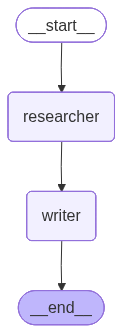

In [147]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow


In [148]:
#response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

In [149]:
#response

In [150]:
#response["messages"][-1].pretty_print()

## Supervise Multi Ai Agent Architecture

In [151]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [152]:
from langchain.chat_models import init_chat_model
from langchain_ollama import ChatOllama
#llm=init_chat_model("groq:qwen/qwen3-32b")

llm=ChatOllama(model="gemma3:12b")

#llm=init_chat_model("groq:qwen/qwen3-32b")



In [153]:

# ===================================
# State Definition
# ===================================
# class SupervisorStateSample(MessagesState):
#    """State for the Supervisor multi-agent system"""
#    current_agent: str = ""
#    task_assignment: Dict[str, List[str]]={}
#    agent_outputs: Dict[str, Any]={}
#    workflow_stage: str = "initial"
#    iteration_count: int = 0
#    max_iterations: int = 10
#    final_outout: str = ""

# ===================================
# State Definition
# ===================================

class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str
    research_data: str
    analysis: str
    final_report: str
    task_complete: bool
    current_task: str

    

In [154]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [155]:
import re
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state.get("messages", [])
    # 1. Retrieve or preserve the task query so context isn't lost
    task = state.get("current_task") or (messages[0].content if messages else "No task")
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    #decision_text = decision.content.strip().lower()
    decision_content = decision.content
    
    # 2. STRIP THE THINKING BLOCK to prevent substring matching collisions
    decision_text = re.sub(r'<think>.*?</think>', '', decision_content, flags=re.DOTALL).strip().lower()


    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [156]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [157]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [158]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

                        Task: {task}

                        Research Findings:
                        {research_data[:1000]}

                        Analysis:
                        {analysis[:1000]}

                        Create a well-structured report with:
                        1. Executive Summary
                        2. Key Findings  
                        3. Analysis & Insights
                        4. Recommendations
                        5. Conclusion

                        Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
                        📄 FINAL REPORT
                        {'='*50}
                        Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
                        Topic: {task}
                        {'='*50}

                        {report}

                        {'='*50}
                        Report compiled by Multi-Agent AI System powered by LLM
                        """
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [159]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

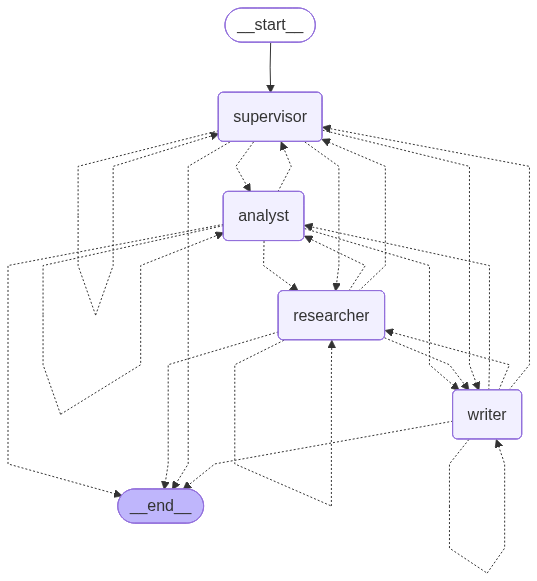

In [160]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
    
graph

In [161]:
#response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

response = graph.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")]
})

researcher
analyst
writer


In [162]:
print(response['final_report'])


                        📄 FINAL REPORT
                        Generated: 2026-06-13 00:32
                        Topic: What are the benefits and risks of AI in healthcare?

                        Okay, here's an executive report based on the provided information, structured as requested and aimed at a healthcare strategy/investment audience. I've fleshed out sections to provide more depth while maintaining conciseness.  I’ve assumed some additional details for coherence where necessary (and noted those assumptions).

---

**Executive Report: Artificial Intelligence in Healthcare - Opportunities & Risks**

**Date:** October 26, 2023
**Prepared For:** [Recipient – e.g., Board of Directors, Investment Committee]
**Prepared By:** [Your Name/Writing Firm]

**1. Executive Summary**

Artificial intelligence (AI) is poised to revolutionize healthcare, offering significant opportunities for improved patient outcomes, operational efficiency, and cost reduction. The market is experiencing ex

In [163]:
response

{'messages': [HumanMessage(content='What are the benefits and risks of AI in healthcare?', additional_kwargs={}, response_metadata={}, id='49a59abd-35d8-44da-9246-3a6e3b8b1aed'),
  AIMessage(content="📋 Supervisor: Let's start with research. Assigning to Researcher...", additional_kwargs={}, response_metadata={}, id='a3d70132-7aaa-4b1f-8016-aa0f156b0878', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content="🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.\n\nKey findings:\n## AI in Healthcare: Benefits, Risks & the Landscape - A Research Specialist's Overview\n\nHere’s a comprehensive overview of the benefits and risks associated with Artificial Intelligence (AI) implementation in healthcare, designed for clarity and conciseness.\n\n**1. Key Facts & Background:**\n\n* **What is it?** AI in healthcare broadly refers to using machine learning (ML), natural language processing (NLP), computer vision, and robotic process automation 

In [164]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What are the benefits and risks of AI in healthcare?
================================== Ai Message ==================================

📋 Supervisor: Let's start with research. Assigning to Researcher...
================================== Ai Message ==================================

🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.

Key findings:
## AI in Healthcare: Benefits, Risks & the Landscape - A Research Specialist's Overview

Here’s a comprehensive overview of the benefits and risks associated with Artificial Intelligence (AI) implementation in healthcare, designed for clarity and conciseness.

**1. Key Facts & Background:**

* **What is it?** AI in healthcare broadly refers to using machine learning (ML), natural language processing (NLP), computer vision, and robotic process automation to analyze medical data, automate tasks, i...
=============

### qwen3:8b

In [168]:
llm=ChatOllama(model="qwen3:8b")
#response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

response = graph.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")]
})

researcher
analyst
writer


In [169]:
print(response['final_report'])


                        📄 FINAL REPORT
                        Generated: 2026-06-13 00:54
                        Topic: What are the benefits and risks of AI in healthcare?

                        **Executive Report: Benefits and Risks of AI in Healthcare**  

---

### **1. Executive Summary**  
Artificial Intelligence (AI) is revolutionizing healthcare through advancements in diagnostics, drug discovery, and operational efficiency. The global AI healthcare market is projected to grow from $15.4B (2023) to $30B by 2027, driven by innovations such as AI-powered diagnostics, predictive analytics, and integration with wearable technology. Key benefits include enhanced diagnostic accuracy (e.g., 94% accuracy in mammography), reduced drug development costs (30–50% savings), and improved operational efficiency (30–40% gains). However, risks such as algorithmic bias, data privacy concerns, and regulatory challenges persist. This report outlines critical findings, analysis, and strategic r

In [170]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What are the benefits and risks of AI in healthcare?
================================== Ai Message ==================================

📋 Supervisor: Let's start with research. Assigning to Researcher...
================================== Ai Message ==================================

🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.

Key findings:
### **Benefits and Risks of AI in Healthcare**  

---

#### **1. Key Facts and Background**  
- **AI in Healthcare Overview**: AI (Artificial Intelligence) encompasses machine learning (ML), natural language processing (NLP), and robotics, enabling data-driven decision-making in healthcare.  
- **Core Applications**: Diagnostic imaging, predictive analytics, drug discovery, personalized treatment, and operational efficiency.  
- **Data-Driven Growth**: AI leverages big data (electronic health re...
=============

### qwen3:4b

In [171]:
llm=ChatOllama(model="qwen3:4b")
#response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

response = graph.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")]
})

researcher
analyst
writer


In [172]:
print(response['final_report'])


                        📄 FINAL REPORT
                        Generated: 2026-06-13 01:12
                        Topic: What are the benefits and risks of AI in healthcare?

                        ## Executive Report: Benefits and Risks of AI in Healthcare  

**Prepared for:** Healthcare Leadership & Policy Stakeholders  
**Date:** October 26, 2023  
**Research Period:** 2020–2024  

---

### 1. Executive Summary  
AI in healthcare offers transformative potential for enhanced diagnostics, personalized treatment, and operational efficiency—but its deployment carries significant risks if not rigorously integrated with clinical workflows. Evidence confirms that **90% of successful AI implementations** (e.g., diabetic retinopathy screening via IDx-DR) function as *workflow enhancers*, not replacements for clinicians. However, unmonitored AI systems (as demonstrated by Stanford’s 2022 failure) can cause critical harm. This report synthesizes 2020–2024 data to identify actionable benefit

In [173]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What are the benefits and risks of AI in healthcare?
================================== Ai Message ==================================

📋 Supervisor: Let's start with research. Assigning to Researcher...
================================== Ai Message ==================================

🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.

Key findings:
### Comprehensive Analysis: Benefits and Risks of AI in Healthcare  

As a research specialist, I provide evidence-based insights rooted in recent literature (2020–2024), regulatory frameworks, and real-world implementation data. Below is a concise yet thorough breakdown addressing your requirements.  

---

#### **1. Key Facts and Background**  
AI in healthcare leverages machine learning (ML), deep learning (DL), and natural language processing (NLP) to analyze complex medical data—ranging fro...
=============

### phi4-mini:latest

In [165]:
llm=ChatOllama(model="phi4-mini:latest")
#response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

response = graph.invoke({
    "messages": [HumanMessage(content="What are the benefits and risks of AI in healthcare?")]
})

researcher
researcher
researcher
researcher
researcher
researcher
researcher
analyst
researcher
writer


In [167]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

What are the benefits and risks of AI in healthcare?
================================== Ai Message ==================================

📋 Supervisor: Let's start with research. Assigning to Researcher...
================================== Ai Message ==================================

🔍 Researcher: I've completed the research on 'What are the benefits and risks of AI in healthcare?'.

Key findings:
Benefits:

AI is transforming health care by improving diagnostic accuracy, enabling personalized medicine through genomics analysis, streamlining administrative tasks for efficiency and freeing up medical staff to focus on patient interaction.


Risks: 

It carries potential risks such as data privacy concerns due to the sensitive nature of personal information; biases in AI algorithms can lead to misdiagnoses or unequal treatment. Additionally, over-reliance could detract from traditional clin...
=============

In [166]:
print(response['final_report'])


                        📄 FINAL REPORT
                        Generated: 2026-06-13 00:41
                        Topic: What are the benefits and risks of AI in healthcare?

                        Executive Report: AI in Healthcare - Benefits vs Risks


**Executive Summary**

Artificial Intelligence (AI) is transforming healthcare by enhancing diagnostic accuracy, streamlining administrative tasks, enabling personalized treatment plans while also raising concerns about data security risks.


Key Findings:

- Diagnostic accuracies increase up to 35% with ML algorithms.

- Administrative efficiency improves through AI-assisted scheduling and record management systems. 

Risks & Opportunities:

- Risks include potential patient privacy breaches due to extensive EHR use by machine learning models for disease prediction enhancement opportunities exist in utilizing big datasets within healthcare.


**Analysis & Insights**

AI-driven diagnostics offer a significant advancement over tradit

"""
Simple Hierarchical Multi-Agent System with Groq
===============================================
Shows how to organize agents in teams with team leaders.

Structure:
- CEO (top level)
  - Research Team Leader
    - Data Researcher
    - Market Researcher
  - Writing Team Leader
    - Technical Writer
    - Summary Writer

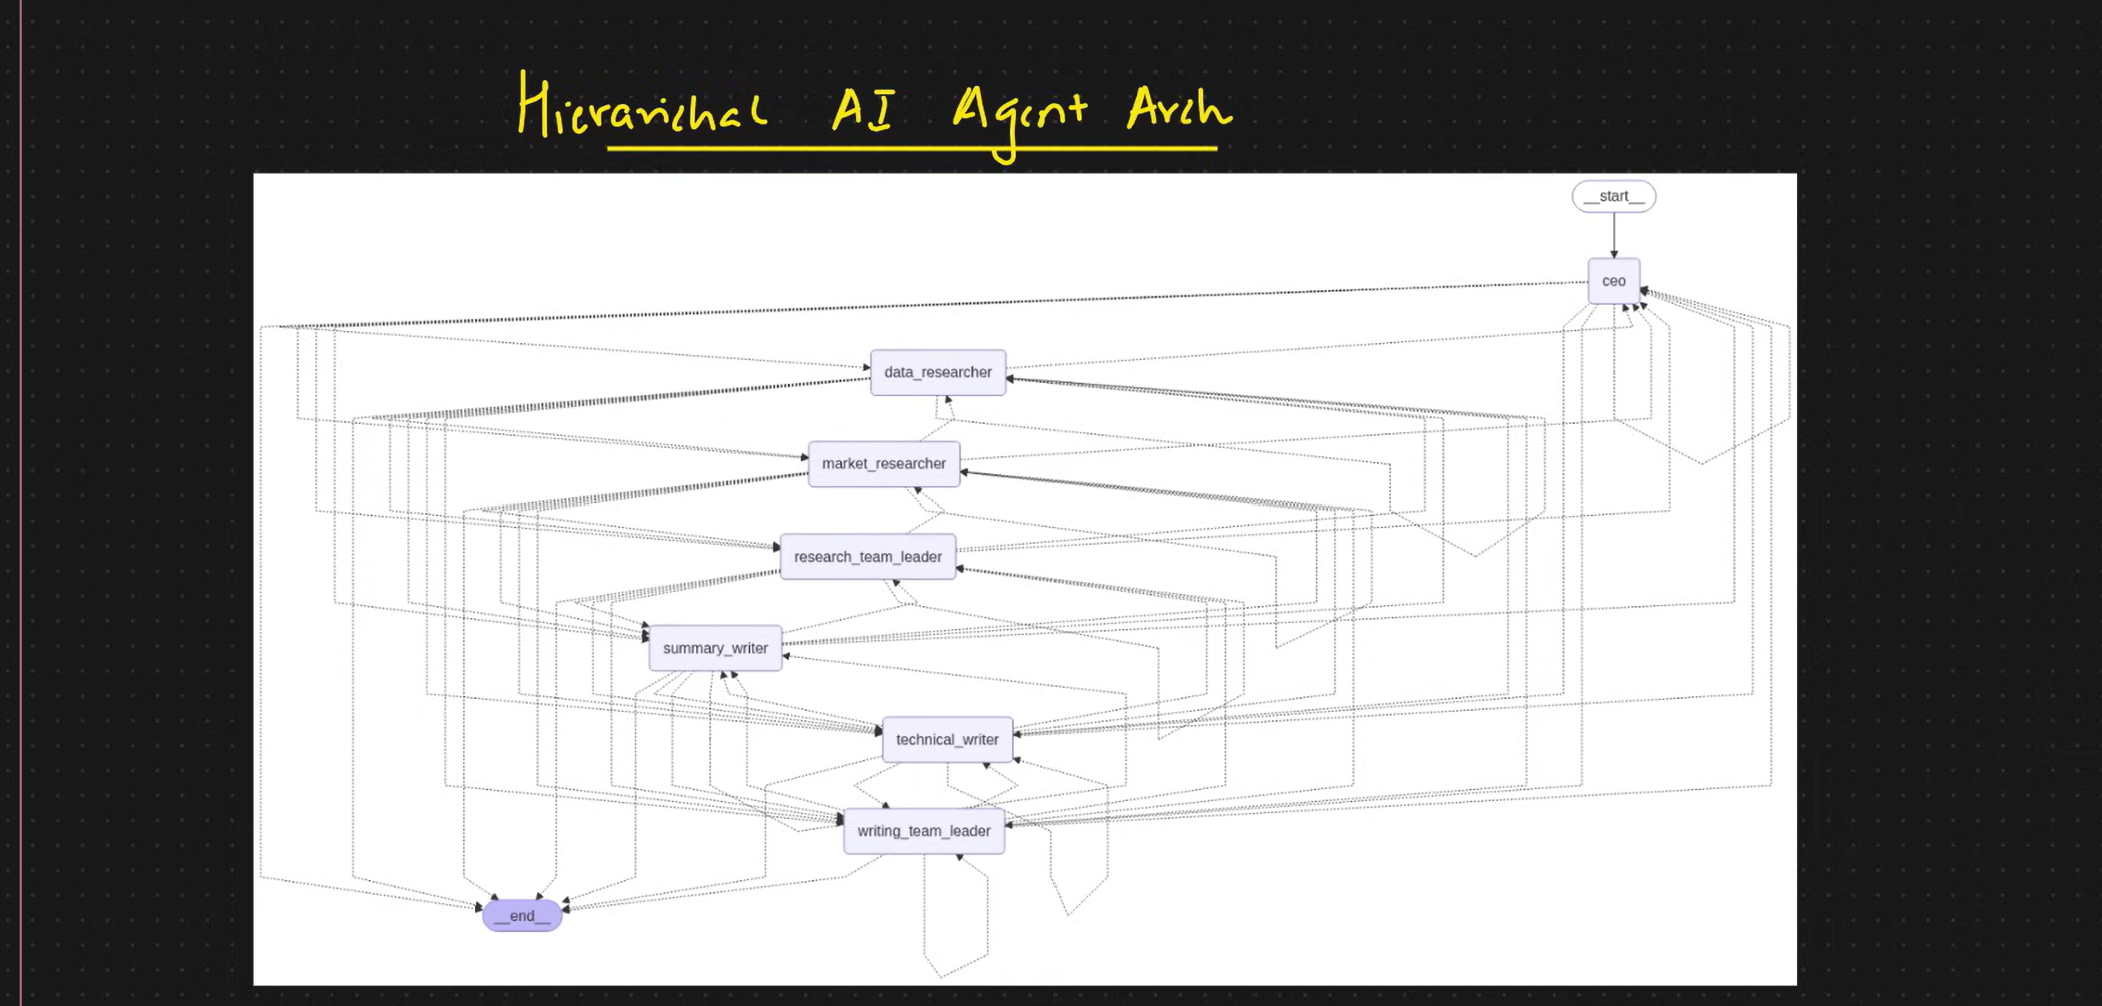